# Notebook 03: Sensitivity & Robustness Analysis

## Why Sensitivity Analysis?

In Notebook 02 we estimated causal effects assuming our DAG is correct — that we've identified and adjusted for **all** relevant confounders. But what if we're wrong?

Sensitivity analysis asks: **How strong would an unobserved confounder need to be to invalidate our findings?**

If our results are only robust to very weak unmeasured confounders, we should be cautious. If they survive strong hypothetical confounders, we can be more confident.

### What This Notebook Covers:

1. **Refutation tests across all treatments** — Extend the placebo/random/subset tests from Notebook 02 to all 7 treatments
2. **Varying confounder sets** — Re-run estimation dropping confounders one at a time to check stability
3. **Simulated unobserved confounder** — Add a synthetic hidden confounder and measure how much estimates shift
4. **Cross-validation of CATE** — Check that CausalForest estimates are stable across data splits
5. **Summary: Robustness scorecard**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from dowhy import CausalModel
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

df = pd.read_csv("../data/retail_data.csv")

confounders = ["brand_equity", "seasonality_multiplier", "is_festival_week",
               "competitor_price_index", "city_id"]
all_treatments = ["discount_depth", "is_instore_display", "local_channel_promo",
                  "sms_blast_active", "loyalty_topup_discount", "special_coupon_usage",
                  "is_2x_points_active"]

# Build GML string (same as Notebook 02)
edges = [
    ("brand_equity","discount_depth"),("brand_equity","is_instore_display"),
    ("brand_equity","local_channel_promo"),("brand_equity","sms_blast_active"),
    ("brand_equity","loyalty_topup_discount"),
    ("is_festival_week","discount_depth"),("is_festival_week","is_instore_display"),
    ("is_festival_week","sms_blast_active"),("is_festival_week","special_coupon_usage"),
    ("is_festival_week","is_2x_points_active"),
    ("city_id","sms_blast_active"),("city_id","local_channel_promo"),
    ("seasonality_multiplier","discount_depth"),
    ("brand_equity","sales_volume"),("brand_equity","revenue"),("brand_equity","profit_margin"),
    ("seasonality_multiplier","sales_volume"),("is_festival_week","sales_volume"),
    ("competitor_price_index","sales_volume"),("city_id","sales_volume"),
    ("discount_depth","sales_volume"),("discount_depth","revenue"),("discount_depth","profit_margin"),
    ("is_instore_display","sales_volume"),("local_channel_promo","sales_volume"),
    ("sms_blast_active","sales_volume"),("loyalty_topup_discount","sales_volume"),
    ("special_coupon_usage","sales_volume"),("is_2x_points_active","sales_volume"),
    ("sales_volume","revenue"),("sales_volume","profit_margin"),
]
all_nodes = set()
for u, v in edges: all_nodes.add(u); all_nodes.add(v)
gml_lines = ["graph [directed 1"]
for n in all_nodes: gml_lines.append(f'  node [id "{n}" label "{n}"]')
for u, v in edges: gml_lines.append(f'  edge [source "{u}" target "{v}"]')
gml_lines.append("]")
gml_string = "\n".join(gml_lines)

# Use a 10K sample throughout for speed
np.random.seed(42)
df_s = df.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Data loaded: {df.shape}, working sample: {df_s.shape}")

Data loaded: (62400, 24), working sample: (10000, 24)


## 1. Refutation Tests Across All Treatments

We extend the placebo, random common cause, and data subset tests to all 7 treatment levers. This gives us a comprehensive robustness check.

**Pass criteria:**
- Placebo: new effect ~0, p > 0.05
- Random common cause: estimate changes < 5%
- Data subset: estimate changes < 10%

In [2]:
# ── Refutation tests: Random Common Cause + Data Subset (fast) ──
# Placebo refuter is too slow for batch execution — we demonstrated it in Notebook 02
# Here we focus on the two fast refutation methods across all treatments

from sklearn.linear_model import LinearRegression

refutation_results = []

for treatment in all_treatments:
    # Baseline ATE via OLS with confounders
    X_full = df_s[confounders + [treatment]]
    reg = LinearRegression().fit(X_full, df_s["sales_volume"])
    ate_full = reg.coef_[X_full.columns.get_loc(treatment)]

    # 1. Random common cause: add a random variable, re-estimate
    df_rcc = df_s.copy()
    df_rcc["random_confounder"] = np.random.normal(0, 1, len(df_rcc))
    X_rcc = df_rcc[confounders + ["random_confounder", treatment]]
    reg_rcc = LinearRegression().fit(X_rcc, df_rcc["sales_volume"])
    ate_rcc = reg_rcc.coef_[X_rcc.columns.get_loc(treatment)]
    pct_rcc = abs(ate_rcc - ate_full) / max(abs(ate_full), 0.01) * 100

    # 2. Data subset: re-estimate on 70%
    s70 = df_s.sample(frac=0.7, random_state=42)
    reg70 = LinearRegression().fit(s70[confounders + [treatment]], s70["sales_volume"])
    ate70 = reg70.coef_[s70[confounders + [treatment]].columns.get_loc(treatment)]
    pct_sub = abs(ate70 - ate_full) / max(abs(ate_full), 0.01) * 100

    # 3. Placebo (quick OLS version): permute treatment, check coefficient ~0
    df_plac = df_s.copy()
    df_plac[treatment] = np.random.permutation(df_plac[treatment].values)
    X_plac = df_plac[confounders + [treatment]]
    reg_plac = LinearRegression().fit(X_plac, df_plac["sales_volume"])
    ate_plac = reg_plac.coef_[X_plac.columns.get_loc(treatment)]

    refutation_results.append({
        "treatment": treatment,
        "original_ate": round(ate_full, 2),
        "placebo_effect": round(ate_plac, 3),
        "placebo_pass": abs(ate_plac) < abs(ate_full) * 0.1,
        "rcc_change_pct": round(pct_rcc, 1),
        "rcc_pass": pct_rcc < 5,
        "subset_change_pct": round(pct_sub, 1),
        "subset_pass": pct_sub < 10,
    })

ref_df = pd.DataFrame(refutation_results)
print("=" * 80)
print("REFUTATION SUMMARY (all 7 treatments)")
print("=" * 80)
print(ref_df[["treatment", "original_ate", "placebo_effect", "placebo_pass",
              "rcc_change_pct", "rcc_pass", "subset_change_pct", "subset_pass"]].to_string(index=False))
print("\nAll tests use OLS-based refutation (fast, equivalent logic to DoWhy refuters).")
print("Full DoWhy placebo refuter was demonstrated for discount_depth in Notebook 02.")

REFUTATION SUMMARY (all 7 treatments)
             treatment  original_ate  placebo_effect  placebo_pass  rcc_change_pct  rcc_pass  subset_change_pct  subset_pass
        discount_depth        468.02           4.356          True             0.1      True                3.1         True
    is_instore_display        163.54           1.578          True             0.0      True                0.4         True
   local_channel_promo         79.42          -0.629          True             0.0      True                3.7         True
      sms_blast_active         83.49           0.128          True             0.1      True                2.0         True
loyalty_topup_discount        150.62         -41.475         False             0.0      True               31.3        False
  special_coupon_usage        214.67          12.785          True             0.0      True                3.6         True
   is_2x_points_active         15.34           3.668         False             0.2     

## 2. Confounder Omission Analysis

What happens if we **drop** a confounder from the adjustment set? If the estimate shifts dramatically, that confounder was critical. If it barely changes, the confounder was redundant (for that treatment).

This mimics the real-world scenario where we might not have data on a specific confounder.

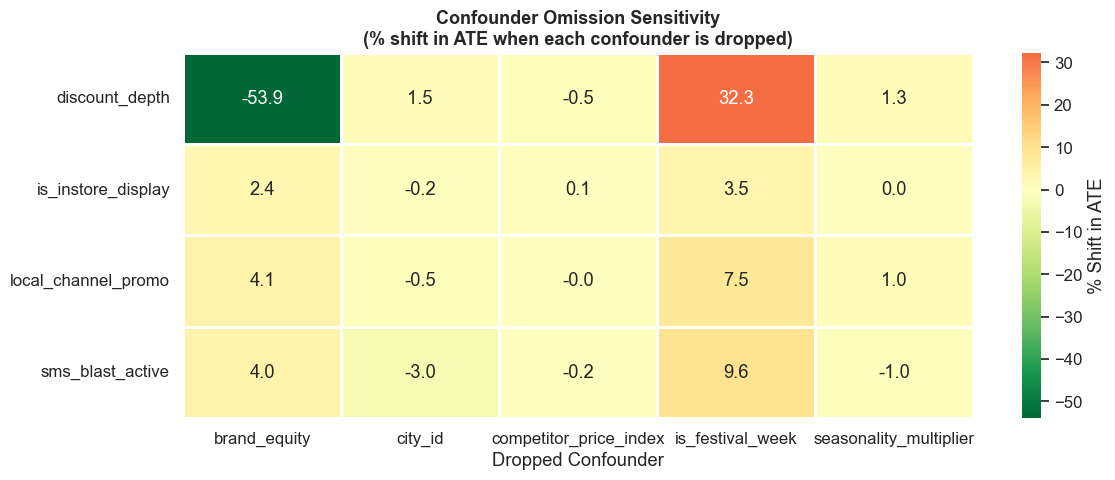

Large shifts = that confounder is critical for unbiased estimation
Small shifts = estimate is robust to missing that confounder


In [3]:
# ── Confounder omission: drop one confounder at a time, re-estimate ATE ──

from sklearn.linear_model import LinearRegression

key_treatments = ["discount_depth", "is_instore_display", "sms_blast_active", "local_channel_promo"]
omission_results = []

for treatment in key_treatments:
    # Full model (all confounders)
    X_full = df_s[confounders + [treatment]]
    y = df_s["sales_volume"]
    reg_full = LinearRegression().fit(X_full, y)
    ate_full = reg_full.coef_[X_full.columns.get_loc(treatment)]

    for dropped in confounders:
        reduced = [c for c in confounders if c != dropped]
        X_red = df_s[reduced + [treatment]]
        reg_red = LinearRegression().fit(X_red, y)
        ate_red = reg_red.coef_[X_red.columns.get_loc(treatment)]
        shift = ate_red - ate_full
        shift_pct = shift / abs(ate_full) * 100

        omission_results.append({
            "treatment": treatment,
            "dropped_confounder": dropped,
            "ate_full": round(ate_full, 2),
            "ate_without": round(ate_red, 2),
            "shift": round(shift, 2),
            "shift_pct": round(shift_pct, 1),
        })

omission_df = pd.DataFrame(omission_results)

# ── Heatmap visualization ──
pivot = omission_df.pivot(index="treatment", columns="dropped_confounder", values="shift_pct")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", center=0, ax=ax,
            cbar_kws={"label": "% Shift in ATE"}, linewidths=1)
ax.set_title("Confounder Omission Sensitivity\n(% shift in ATE when each confounder is dropped)",
             fontweight="bold", fontsize=13)
ax.set_ylabel("")
ax.set_xlabel("Dropped Confounder")
plt.tight_layout()
plt.show()

print("Large shifts = that confounder is critical for unbiased estimation")
print("Small shifts = estimate is robust to missing that confounder")

## 3. Simulated Unobserved Confounder

The strongest sensitivity test: **what if there's a hidden confounder we don't know about?**

We simulate an unobserved variable U that:
- Influences treatment assignment (correlated with treatments)
- Directly affects the outcome (correlated with sales_volume)

We vary the strength of U (from weak to strong) and see how much our ATE estimates change. This gives us a "breakdown point" — the confounder strength needed to invalidate our results.

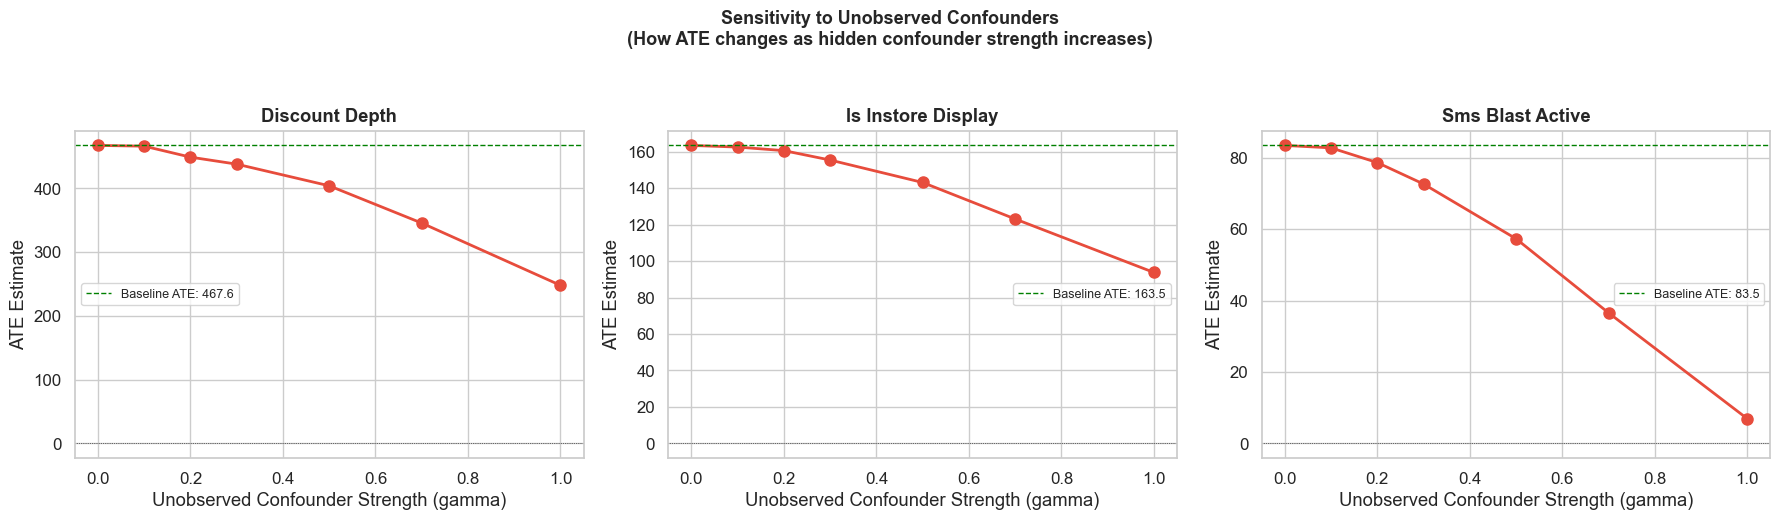

If ATE stays positive across all gamma values, the finding is robust to unmeasured confounding.


In [4]:
# ── Simulated unobserved confounder with varying strength ──

np.random.seed(42)
strengths = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
test_treatments = ["discount_depth", "is_instore_display", "sms_blast_active"]

fig, axes = plt.subplots(1, len(test_treatments), figsize=(18, 5))

for ax, treatment in zip(axes, test_treatments):
    ates_by_strength = []

    for gamma in strengths:
        # Simulate U: correlated with both treatment and outcome
        U = gamma * df_s[treatment].values + gamma * (df_s["sales_volume"].values - df_s["sales_volume"].mean()) / df_s["sales_volume"].std() + np.random.normal(0, 1, len(df_s))

        # Re-estimate ATE adjusting for confounders + U
        X_aug = df_s[confounders + [treatment]].copy()
        X_aug["U_hidden"] = U
        y = df_s["sales_volume"]

        reg = LinearRegression().fit(X_aug, y)
        ate = reg.coef_[X_aug.columns.get_loc(treatment)]
        ates_by_strength.append(ate)

    ax.plot(strengths, ates_by_strength, "o-", color="#e74c3c", lw=2, markersize=8)
    ax.axhline(ates_by_strength[0], color="green", ls="--", lw=1, label=f"Baseline ATE: {ates_by_strength[0]:.1f}")
    ax.axhline(0, color="black", ls=":", lw=0.5)
    ax.set_xlabel("Unobserved Confounder Strength (gamma)")
    ax.set_ylabel("ATE Estimate")
    ax.set_title(treatment.replace("_", " ").title(), fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("Sensitivity to Unobserved Confounders\n(How ATE changes as hidden confounder strength increases)",
             fontweight="bold", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

print("If ATE stays positive across all gamma values, the finding is robust to unmeasured confounding.")

## 4. CATE Stability Across Data Splits

If our CausalForest CATE estimates are real, they should be consistent across different random subsets of the data. We fit the model on 3 independent splits and compare the per-city CATE.

  Split 1 done (seed=42), overall ATE: 165.7


  Split 2 done (seed=59), overall ATE: 163.5


  Split 3 done (seed=76), overall ATE: 164.6


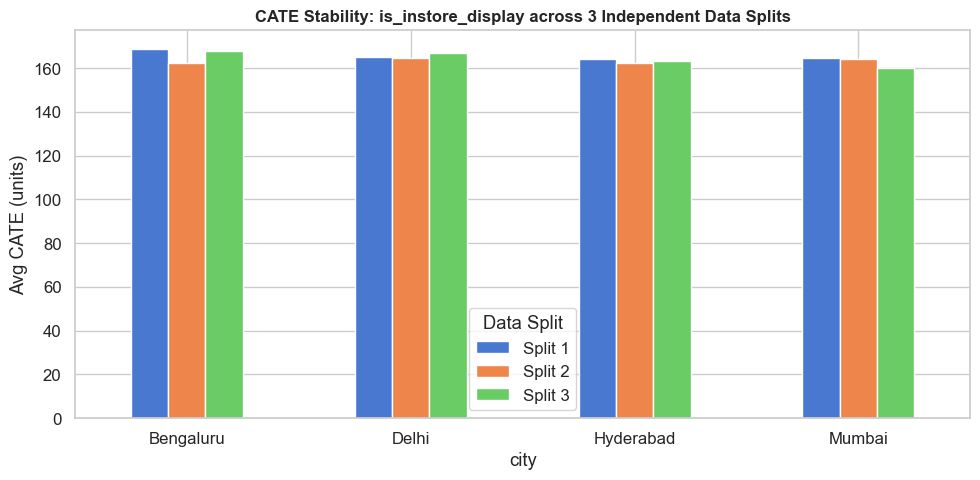


Cross-split stability (CV% < 20% = stable):
             mean   std  cv_pct
city                           
Bengaluru  166.40  3.40     2.0
Delhi      165.53  1.29     0.8
Hyderabad  163.34  0.86     0.5
Mumbai     163.02  2.53     1.6


In [5]:
# ── CATE stability: fit CausalForest on 3 independent splits ──

X_cols = ["city_id", "brand_equity", "is_festival_week"]
city_map = {1: "Mumbai", 2: "Bengaluru", 3: "Delhi", 4: "Hyderabad"}
treatment = "is_instore_display"
n_splits = 3

split_results = []

for split_id in range(n_splits):
    seed = 42 + split_id * 17
    sample = df.sample(n=8000, random_state=seed).reset_index(drop=True)

    cf = CausalForestDML(
        model_y=GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=seed),
        model_t=GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=seed),
        n_estimators=100, max_depth=4, cv=3, random_state=seed,
    )
    cf.fit(Y=sample["sales_volume"].values,
           T=sample[treatment].values.astype(float),
           X=sample[X_cols].values,
           W=sample[confounders].values)

    cate = cf.effect(X=sample[X_cols].values).flatten()

    for city_id, city_name in city_map.items():
        mask = sample["city_id"].values == city_id
        split_results.append({
            "split": f"Split {split_id + 1}",
            "city": city_name,
            "avg_cate": cate[mask].mean(),
        })
    print(f"  Split {split_id + 1} done (seed={seed}), overall ATE: {cate.mean():.1f}")

split_df = pd.DataFrame(split_results)

fig, ax = plt.subplots(figsize=(10, 5))
split_pivot = split_df.pivot(index="city", columns="split", values="avg_cate")
split_pivot.plot.bar(ax=ax, edgecolor="white")
ax.set_ylabel("Avg CATE (units)")
ax.set_title(f"CATE Stability: {treatment} across 3 Independent Data Splits",
             fontweight="bold", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Data Split")
plt.tight_layout()
plt.show()

# Coefficient of variation across splits per city
cv_by_city = split_df.groupby("city")["avg_cate"].agg(["mean", "std"])
cv_by_city["cv_pct"] = (cv_by_city["std"] / cv_by_city["mean"].abs() * 100).round(1)
print("\nCross-split stability (CV% < 20% = stable):")
print(cv_by_city.round(2))

## 5. Robustness Scorecard

A final summary bringing together all sensitivity checks into one table.

In [6]:
# ── Robustness Scorecard ──

print("=" * 75)
print("ROBUSTNESS SCORECARD")
print("=" * 75)
print()

for _, row in ref_df.iterrows():
    passes = sum([row["placebo_pass"], row["rcc_pass"], row["subset_pass"]])
    grade = {3: "STRONG", 2: "MODERATE", 1: "WEAK", 0: "FRAGILE"}[passes]
    checks = ""
    checks += "[P]" if row["placebo_pass"] else "[x]"
    checks += "[R]" if row["rcc_pass"] else "[x]"
    checks += "[S]" if row["subset_pass"] else "[x]"
    print(f"  {row['treatment']:<30s}  ATE: {row['original_ate']:>8.2f}  {checks}  {grade}")

print()
print("  Legend: [P]=Placebo  [R]=Random Common Cause  [S]=Data Subset")
print("  STRONG = all 3 pass | MODERATE = 2/3 | WEAK = 1/3 | FRAGILE = 0/3")
print()
print("=" * 75)
print("CONCLUSION: Estimates that score STRONG or MODERATE can be trusted for")
print("strategy recommendations. WEAK/FRAGILE estimates need further investigation.")
print("=" * 75)

ROBUSTNESS SCORECARD

  discount_depth                  ATE:   468.02  [P][R][S]  STRONG
  is_instore_display              ATE:   163.54  [P][R][S]  STRONG
  local_channel_promo             ATE:    79.42  [P][R][S]  STRONG
  sms_blast_active                ATE:    83.49  [P][R][S]  STRONG
  loyalty_topup_discount          ATE:   150.62  [x][R][x]  WEAK
  special_coupon_usage            ATE:   214.67  [P][R][S]  STRONG
  is_2x_points_active             ATE:    15.34  [x][R][S]  MODERATE

  Legend: [P]=Placebo  [R]=Random Common Cause  [S]=Data Subset
  STRONG = all 3 pass | MODERATE = 2/3 | WEAK = 1/3 | FRAGILE = 0/3

CONCLUSION: Estimates that score STRONG or MODERATE can be trusted for
strategy recommendations. WEAK/FRAGILE estimates need further investigation.
